In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def make_W(N, J, rng, kind="gaussian", p=None):
    """Build recurrent connectivity matrix."""
    if kind == "gaussian":
        return rng.normal(0.0, J / np.sqrt(N), size=(N, N))
    if kind == "erdos_renyi":
        if p is None:
            raise ValueError("need p")
        k = max(int(p * N), 1)
        return ((rng.random((N, N)) < p) * (J / k)).astype(float)
    raise ValueError("kind must be 'gaussian' or 'erdos_renyi'")

In [3]:
def init_r(N, kind="uniform", scale=0.01, rng=None):
    """Random initial firing rates."""
    if rng is None:
        rng = np.random.default_rng()
    if kind == "uniform":
        return rng.uniform(-scale, scale, size=N)
    if kind == "gaussian":
        return rng.normal(0.0, scale, size=N)
    if kind == "zeros":
        return np.zeros(N)
    if kind == "ones":
        return np.ones(N)
    raise ValueError("kind must be 'uniform', 'gaussian', 'zeros', or 'ones'")

In [4]:
def simulate(r_0, W, time):
    """Euler integration of the rate model. Returns R of shape (T, N)."""
    r_0 = np.asarray(r_0, dtype=float)
    W   = np.asarray(W,   dtype=float)
    dt  = time[1] - time[0]
    T   = len(time)
    N   = len(r_0)
    R   = np.empty((T, N))
    R[0] = r_0
    for t in range(T - 1):
        r      = R[t]
        R[t+1] = r + dt * (-r + np.tanh(W @ r))
    return R

In [5]:
def plot_trajectories(time, R, num_neurons=5, title="Neuron Trajectories"):
    """Plot the time trajectories of a subset of neurons."""
    plt.figure(figsize=(10, 5))
    
    # R has shape (T, N). Select the first 'num_neurons' for plotting
    for i in range(min(num_neurons, R.shape[1])):
        plt.plot(time, R[:, i], label=f"Neuron {i+1}")
        
    plt.xlabel("Time (t)")
    plt.ylabel("Firing rate $r_i(t)$")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [6]:
def plot_statistics_vs_J(N, time, J_values, num_trials=10, rng=None):
    """
    Simulate the network for multiple trials across different J values.
    Plots the mean temporal variance and mean absolute firing rate
    with shaded regions indicating the standard deviation across trials.
    """
    if rng is None:
        rng = np.random.default_rng()
        
    # Discard the first 20% of the simulation to remove initial transients
    burn_in = int(0.2 * len(time))
    
    # Matrices to store results: shape (number of J values, number of trials)
    all_variances = np.zeros((len(J_values), num_trials))
    all_abs_rates = np.zeros((len(J_values), num_trials))
    
    print("Running simulations. This might take a while...")
    
    for i, J in enumerate(J_values):
        for trial in range(num_trials):
            # 1. Build network and initial conditions for this specific trial
            W = make_W(N, J, rng, kind="gaussian")
            r0 = init_r(N, rng=rng)
            
            # 2. Simulate
            R = simulate(r0, W, time)
            
            # 3. Keep only the steady state (discard burn-in)
            R_steady = R[burn_in:, :]
            
            # --- Temporal Variance ---
            # Variance over time for each neuron, then mean across all neurons
            var_over_time = np.var(R_steady, axis=0) 
            mean_var = np.mean(var_over_time)
            all_variances[i, trial] = mean_var
            
            # --- Absolute Firing Rate ---
            # Mean of absolute values across time and neurons
            mean_abs = np.mean(np.abs(R_steady))
            all_abs_rates[i, trial] = mean_abs

    # ==========================
    # Plotting the results
    # ==========================
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Compute mean and standard deviation across trials
    mean_v = np.mean(all_variances, axis=1)
    std_v = np.std(all_variances, axis=1)
    
    mean_r = np.mean(all_abs_rates, axis=1)
    std_r = np.std(all_abs_rates, axis=1)
    
    # --- Left Plot: Mean temporal variance ---
    ax1 = axes[0]
    # Faint lines for individual trials
    ax1.plot(J_values, all_variances, color='tab:red', alpha=0.05, linewidth=1)
    ax1.plot(J_values, all_variances, color='tab:blue', alpha=0.05, linewidth=1) # Mixing colors to match screenshot aesthetic
    # Main line and shaded area
    ax1.plot(J_values, mean_v, color='tab:blue', linewidth=2)
    ax1.fill_between(J_values, mean_v - std_v, mean_v + std_v, color='tab:blue', alpha=0.2)
    # Critical J line
    ax1.axvline(1.0, linestyle='--', color='tab:blue')
    
    ax1.set_title("Mean temporal variance")
    ax1.set_xlabel("J")
    ax1.set_ylabel(r"$\langle\sigma_i^2\rangle$")
    ax1.set_xlim(min(J_values), max(J_values))
    ax1.set_ylim(bottom=0)
    
    # --- Right Plot: Mean absolute firing rate ---
    ax2 = axes[1]
    # Faint lines for individual trials
    ax2.plot(J_values, all_abs_rates, color='tab:red', alpha=0.05, linewidth=1)
    ax2.plot(J_values, all_abs_rates, color='tab:blue', alpha=0.05, linewidth=1)
    # Main line and shaded area
    ax2.plot(J_values, mean_r, color='tab:blue', linewidth=2)
    ax2.fill_between(J_values, mean_r - std_r, mean_r + std_r, color='tab:blue', alpha=0.2)
    # Critical J line
    ax2.axvline(1.0, linestyle='--', color='tab:blue')
    
    ax2.set_title("Mean absolute firing rate")
    ax2.set_xlabel("J")
    ax2.set_ylabel(r"$\langle|r_i|\rangle$")
    ax2.set_xlim(min(J_values), max(J_values))
    ax2.set_ylim(bottom=0)
    
    plt.tight_layout()
    plt.show()

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

def plot_frequency_heatmap_vs_J(N, time, dt, J_values, num_trials=5, rng=None):
    """
    Plots a heatmap (spectrogram) of the average Power Spectral Density across J values.
    X-axis: Coupling strength (J)
    Y-axis: Frequency (Hz) in logarithmic scale
    Color: Mean Power Spectral Density (averaged across neurons and trials)
    """
    if rng is None:
        rng = np.random.default_rng()
        
    # Discard the first 20% to avoid the initial transient phase
    burn_in = int(0.2 * len(time))
    T_steady = len(time) - burn_in
    
    # Calculate frequency bins for the FFT
    freqs = np.fft.rfftfreq(T_steady, d=dt)
    
    # We MUST ignore the 0 Hz (DC component) because log(0) is undefined
    # and it usually contains a massive spike that ruins the color scale
    freqs = freqs[1:]
    
    # Matrix to store the averaged power spectrum for each J
    # Shape: (number of frequency bins, number of J values)
    power_matrix = np.zeros((len(freqs), len(J_values)))
    
    print(f"Calculating Frequency Heatmap ({num_trials} trials per J). This will take a moment...")
    
    for j_idx, J in enumerate(J_values):
        # Accumulator for the power spectra across trials
        sum_power_spectra = np.zeros(len(freqs))
        
        for trial in range(num_trials):
            # 1. Build network and simulate
            W = make_W(N, J, rng, kind="gaussian")
            r0 = init_r(N, rng=rng)
            R = simulate(r0, W, time)
            
            # 2. Extract steady-state activity
            R_steady = R[burn_in:, :]
            
            # 3. Compute FFT (ignoring 0 Hz index 0)
            fft_values = np.fft.rfft(R_steady, axis=0)[1:, :]
            
            # 4. Compute Power Spectral Density
            power = (np.abs(fft_values) ** 2) / T_steady
            
            # 5. Average across all N neurons for this trial
            mean_power_neurons = np.mean(power, axis=1)
            
            # Add to the trial accumulator
            sum_power_spectra += mean_power_neurons
            
        # Average across all trials and store in the main matrix
        power_matrix[:, j_idx] = sum_power_spectra / num_trials
        
        if (j_idx + 1) % 5 == 0:
            print(f"Progress: Computed {j_idx + 1} out of {len(J_values)} J values...")

    # ==========================
    # Plotting the Spectrogram
    # ==========================
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # pcolormesh is ideal for non-linear axes. 
    # LogNorm applies a logarithmic color scale to handle large dynamic ranges in power.
    mesh = ax.pcolormesh(J_values, freqs, power_matrix, 
                         cmap='magma', shading='nearest', 
                         norm=LogNorm())
    
    # Set the Y-axis to logarithmic scale
    ax.set_yscale('log')
    
    # Add a vertical dashed line for the critical J value
    ax.axvline(1.0, color='white', linestyle='--', linewidth=2, label='Critical $J_c = 1.0$')
    
    # Add colorbar
    cbar = fig.colorbar(mesh, ax=ax)
    cbar.set_label("Mean Power (Log Scale)")
    
    ax.set_xlabel("Coupling Strength (J)")
    ax.set_ylabel("Frequency (Hz) [Log Scale]")
    ax.set_title(f"Network Frequency Spectrogram vs J ({num_trials} Trials Avg)")
    ax.legend()
    
    plt.show()

STARTING FULL NETWORK ANALYSIS

--- PART 1: Generating Trajectories ---
Simulating trajectories for J = 0.5...


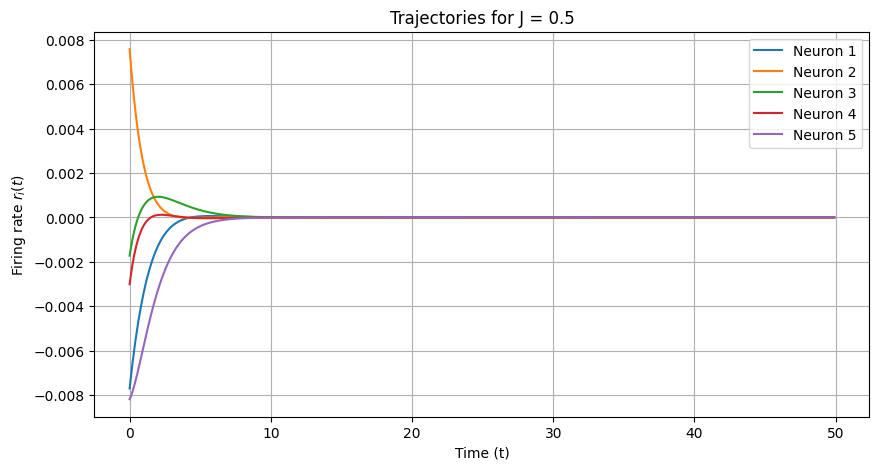

Simulating trajectories for J = 1.0...


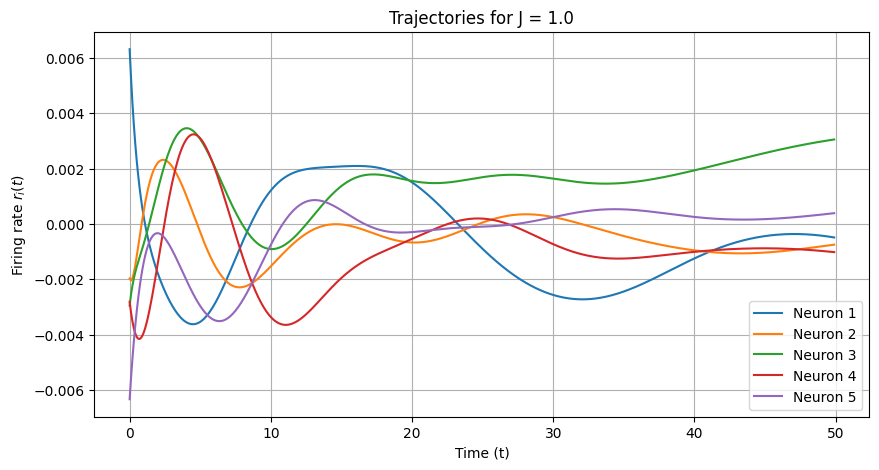

Simulating trajectories for J = 1.5...


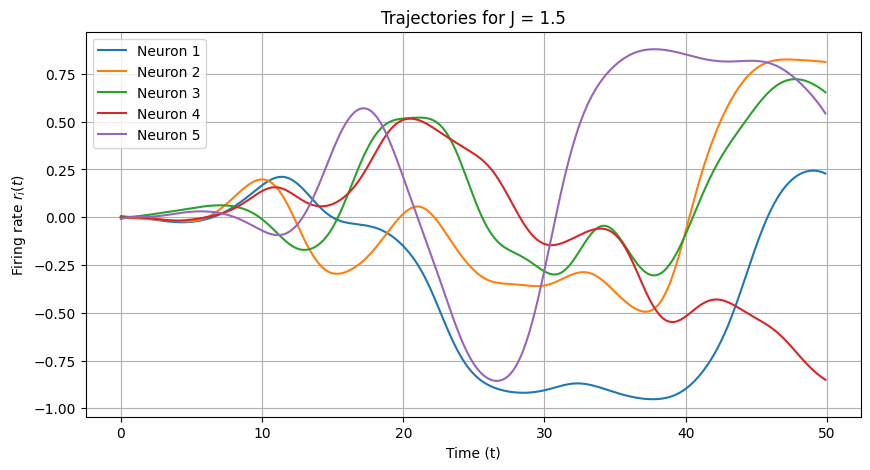

Simulating trajectories for J = 2.0...


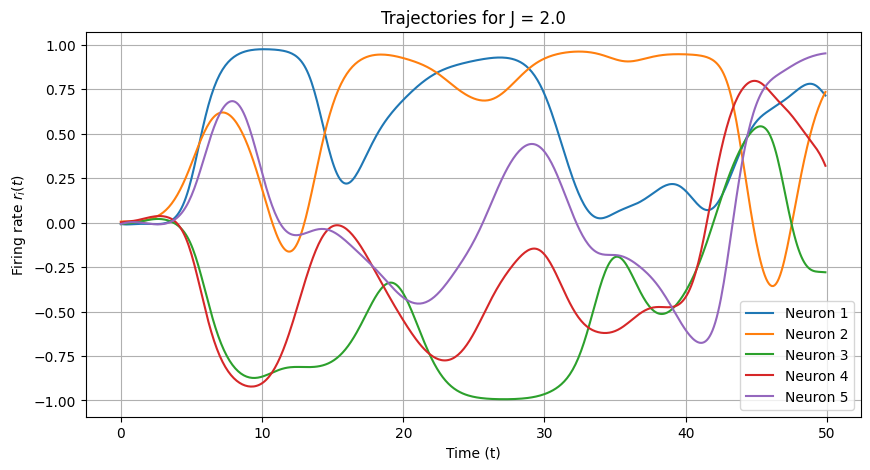


--- PART 2: Generating Statistics vs J (with shaded regions) ---
Running multiple trials. This might take a minute...
Running simulations. This might take a while...


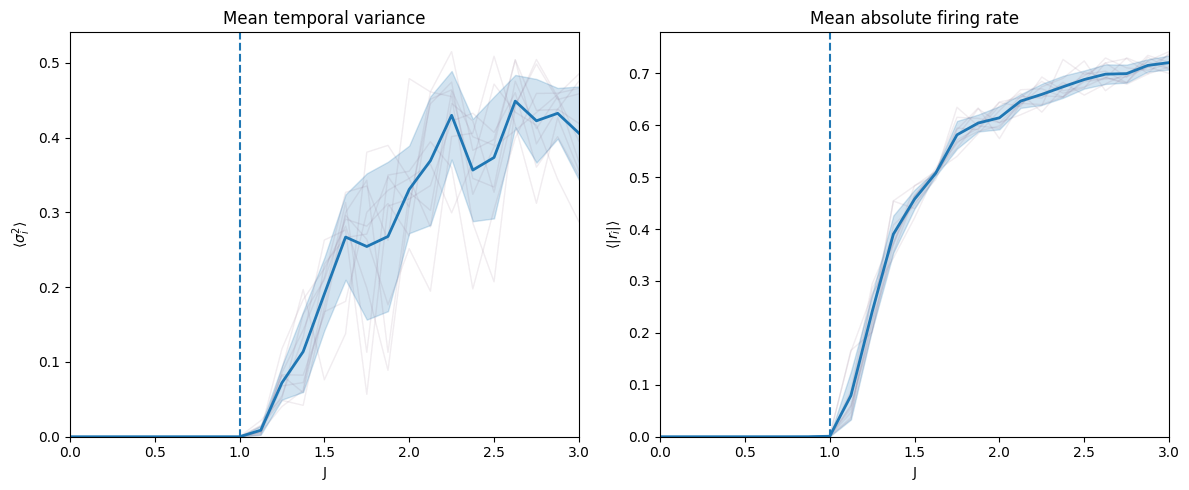


--- PART 3: Generating Frequency Spectrogram ---
Calculating FFT across multiple trials. Almost done...
Calculating Frequency Heatmap (5 trials per J). This will take a moment...
Progress: Computed 5 out of 30 J values...
Progress: Computed 10 out of 30 J values...
Progress: Computed 15 out of 30 J values...
Progress: Computed 20 out of 30 J values...
Progress: Computed 25 out of 30 J values...
Progress: Computed 30 out of 30 J values...


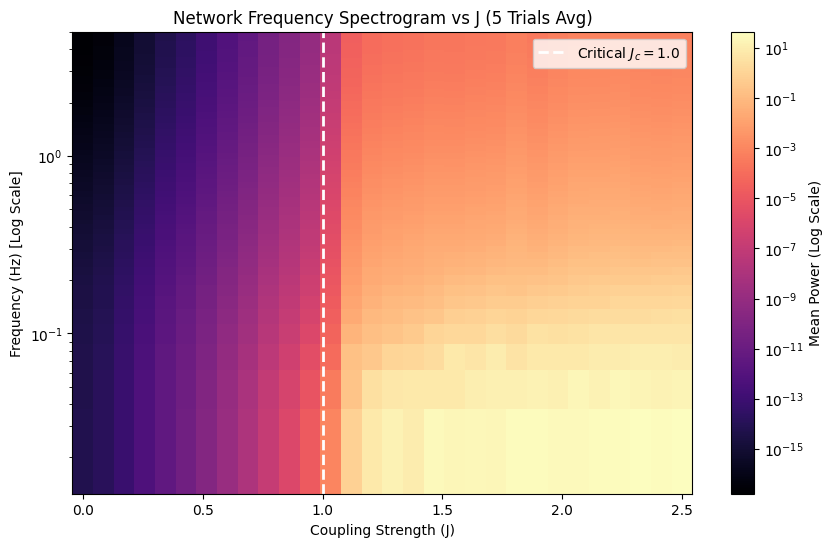


ALL ANALYSES COMPLETED SUCCESSFULLY!


In [8]:
if __name__ == "__main__":
    # Initialize random number generator for reproducibility
    rng = np.random.default_rng(42) 
    
    # Global simulation parameters
    N = 400             # Number of neurons (kept at 400 to balance speed and accuracy)
    T_max = 50.0        # Maximum simulation time
    dt = 0.1            # Time step
    time = np.arange(0, T_max, dt)
    
    print("==================================================")
    print("STARTING FULL NETWORK ANALYSIS")
    print("==================================================\n")

    # -----------------------------------------------------------------
    # PART 1: Trajectories for specific J values
    # -----------------------------------------------------------------
    print("--- PART 1: Generating Trajectories ---")
    J_trajectory_values = [0.5, 1.0, 1.5, 2.0]

    for J in J_trajectory_values:
        print(f"Simulating trajectories for J = {J}...")
        
        # Build network and initial conditions
        W = make_W(N, J, rng, kind="gaussian")
        r0 = init_r(N, rng=rng)
        
        # Run simulation
        R = simulate(r0, W, time)
        
        # Plot
        plot_trajectories(time, R, num_neurons=5, title=f"Trajectories for J = {J}")

    # -----------------------------------------------------------------
    # PART 2: Statistics vs J (Mean variance and Mean absolute rate)
    # -----------------------------------------------------------------
    print("\n--- PART 2: Generating Statistics vs J (with shaded regions) ---")
    print("Running multiple trials. This might take a minute...")
    
    # Values of J from 0.0 to 3.0
    J_stats_values = np.linspace(0.0, 3.0, 25)
    
    # Using 10 trials to get a smooth shaded standard deviation area
    plot_statistics_vs_J(N, time, J_stats_values, num_trials=10, rng=rng)

    # -----------------------------------------------------------------
    # PART 3: Frequency Spectrogram vs J
    # -----------------------------------------------------------------
    print("\n--- PART 3: Generating Frequency Spectrogram ---")
    print("Calculating FFT across multiple trials. Almost done...")
    
    # Array of J values, from 0.0 to 2.5
    J_spectrogram_array = np.linspace(0.0, 2.5, 30)
    
    # Run the function with 5 trials to average out the noise
    plot_frequency_heatmap_vs_J(N, time, dt, J_spectrogram_array, num_trials=5, rng=rng)
    
    print("\n==================================================")
    print("ALL ANALYSES COMPLETED SUCCESSFULLY!")
    print("==================================================")

The spectrogram visualizes the mean Power Spectral Density (PSD) of the network's firing rates across different coupling strengths ($J$), revealing the frequency composition of the network's dynamics.

- Quiescent Regime ($J < 1.0$): The dark region to the left of the critical threshold indicates negligible power across all frequencies (values close to $10^{-15}$). This perfectly aligns with the theoretical prediction that, for weak coupling, the firing rates decay to zero over time, resulting in no sustained oscillations.
    
- Critical Transition ($J_c = 1.0$): At the white dashed line, there is a sharp phase transition. The network abruptly shifts from a silent state to an active state. 
    
- Chaotic Broadband Activity ($J > 1.0$): In the active regime, the energy is not concentrated in a single horizontal line (which would indicate simple periodic/sinusoidal oscillations). Instead, the power is spread across a broad band of frequencies. This wide frequency distribution is the hallmark of deterministic chaos, confirming the theory that the network displays complex, continuously moving activity.
    
- Low-Pass Filtering Effect: Within the chaotic regime, the power is visibly higher at lower frequencies (brighter yellow at the bottom) and gradually decreases at higher frequencies (orange/red at the top). This is due to the $-r_i$ term in the differential equation, which acts as a built-in low-pass filter, preventing the firing rates from changing infinitely fast and favoring slower, macroscopic chaotic waves.
